# Import Depedency

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/drive/MyDrive/bengkod/dataset/Bengkod-Depresi.csv")
df.drop(columns=['id'], inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1.0
1,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0.0
2,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0.0
3,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1.0
4,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0.0


# EDA

## Analisis Univariat

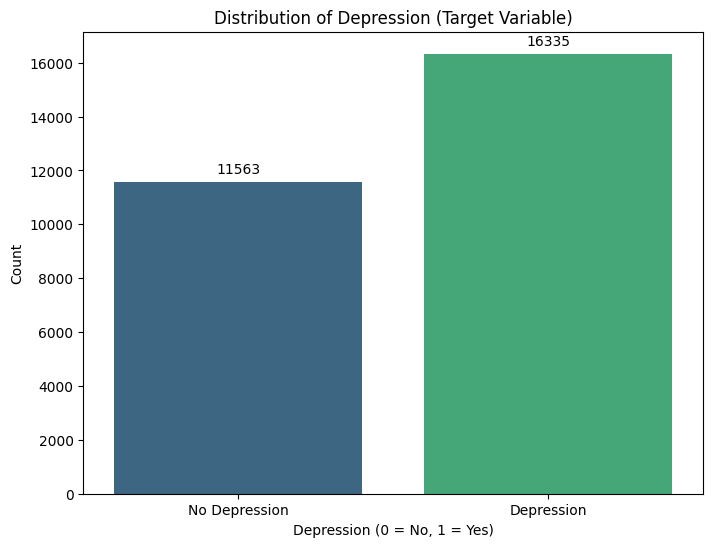

In [3]:
depression_counts = df['Depression'].value_counts()

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=depression_counts.index, y=depression_counts.values, palette='viridis')
plt.title('Distribution of Depression (Target Variable)')
plt.xlabel('Depression (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Depression', 'Depression'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

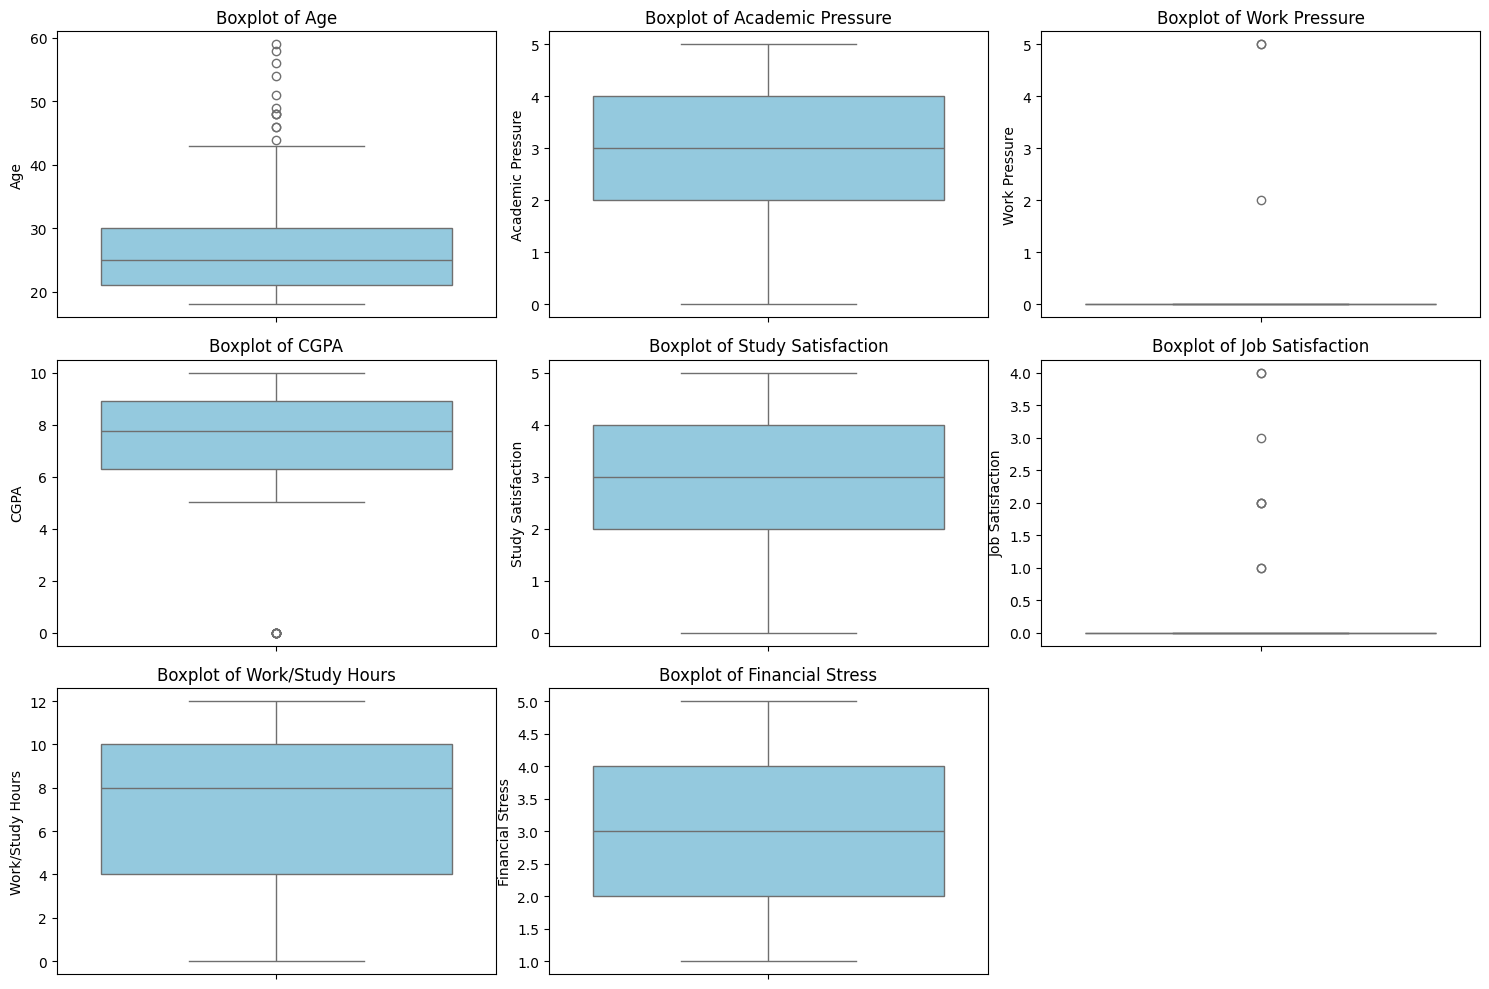

In [4]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['id', 'Depression']]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot((len(numeric_cols) + 2) // 3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

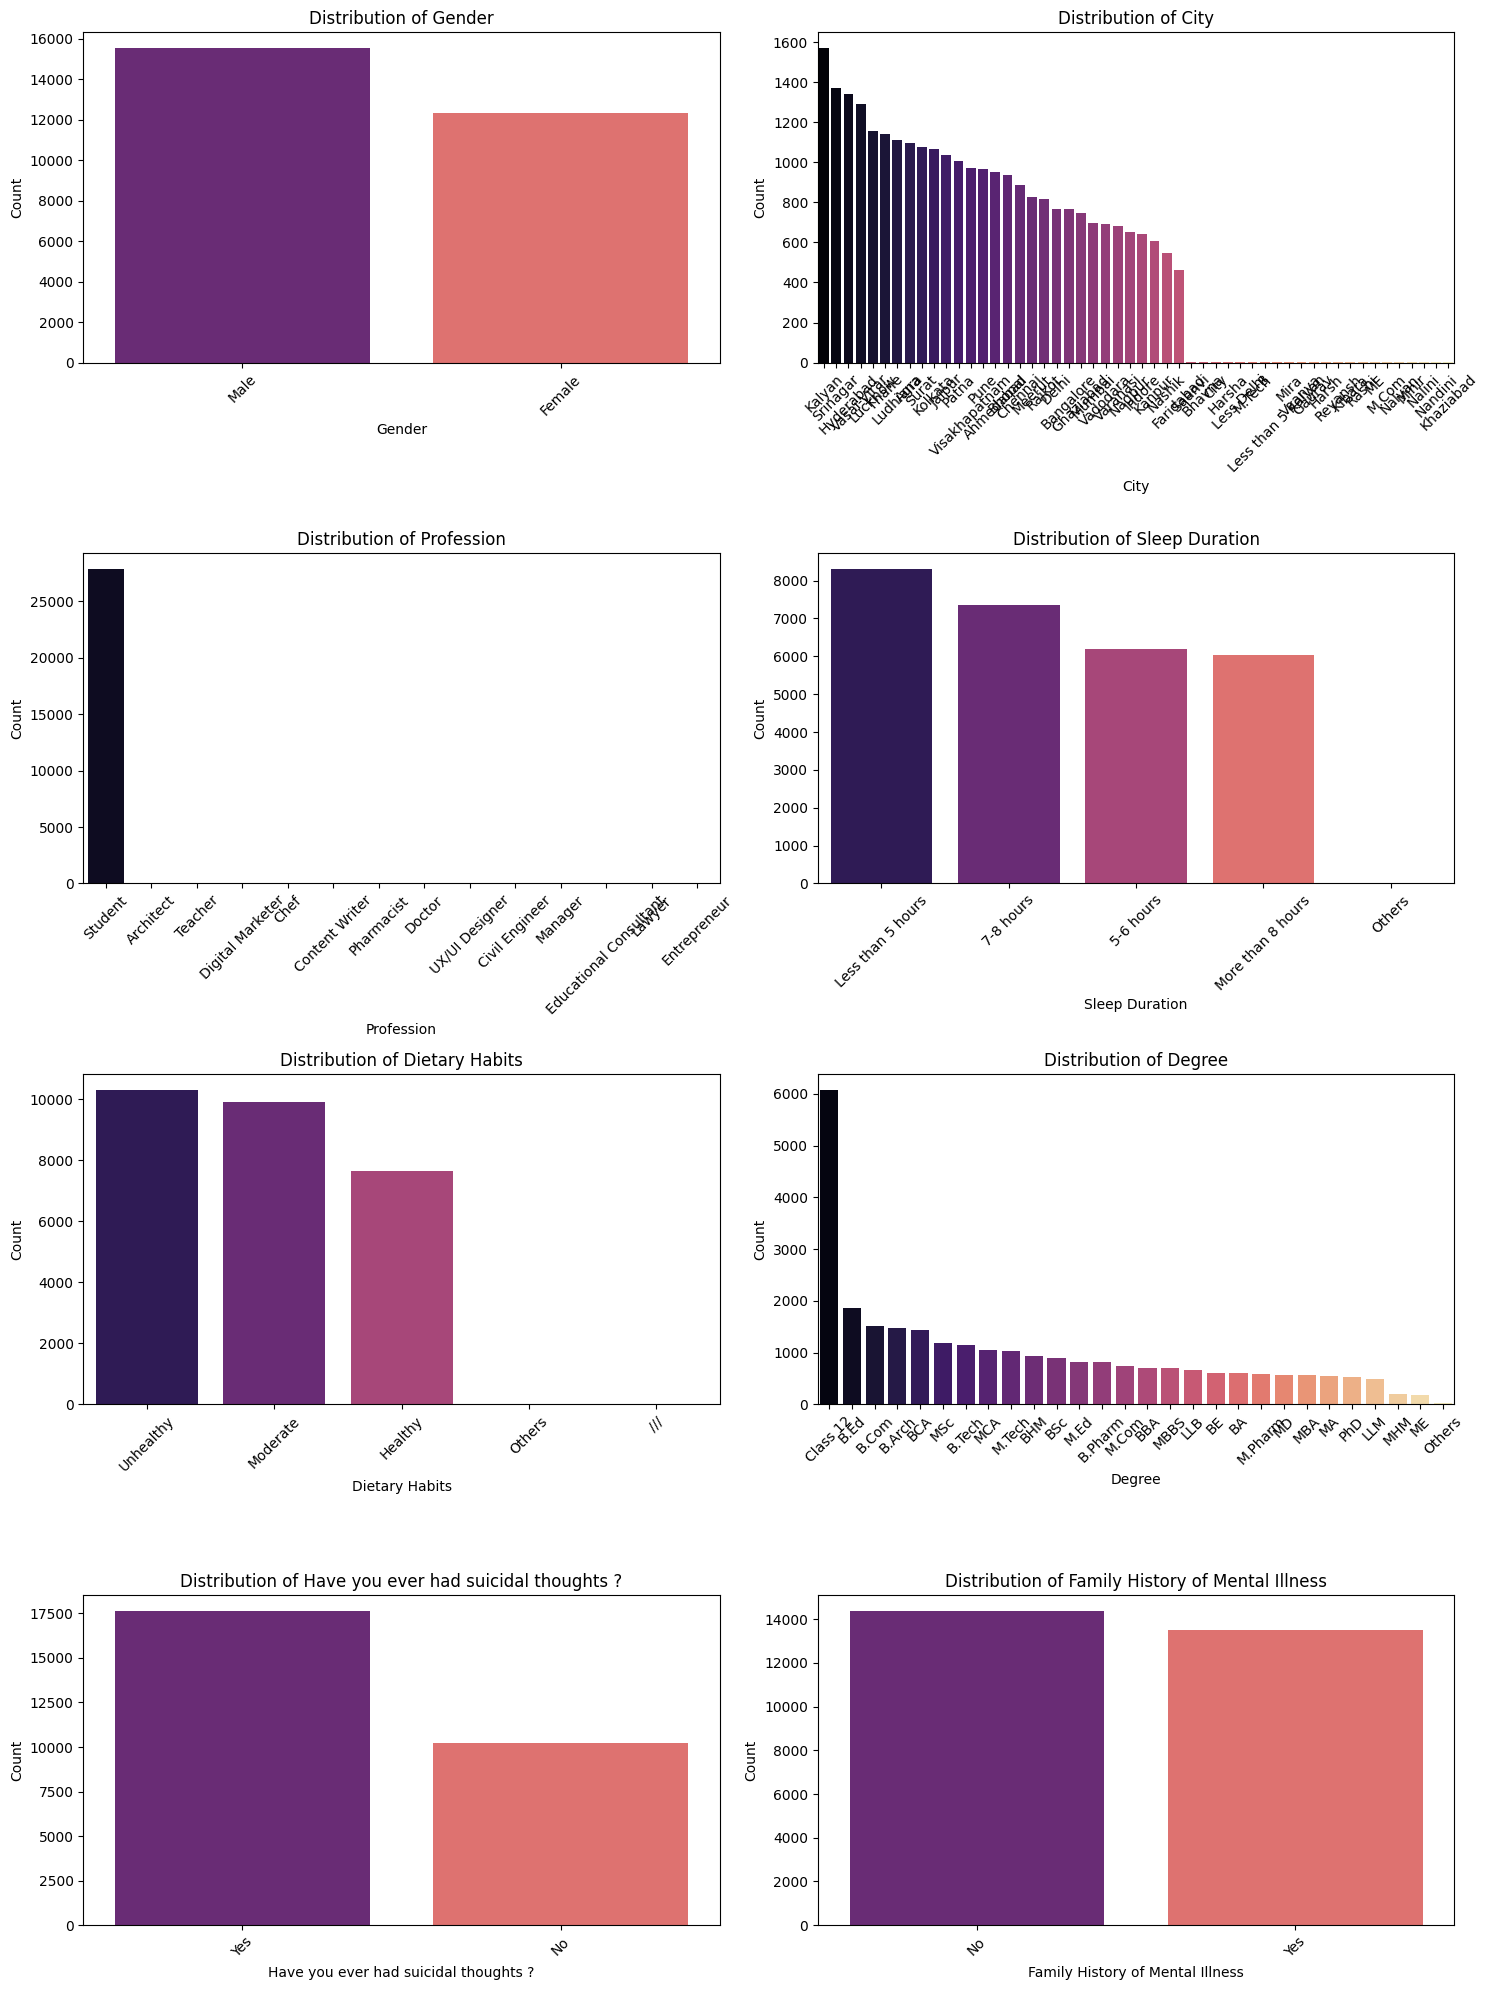

In [5]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Create bar charts for categorical columns
plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot((len(cat_cols) + 1) // 2, 2, i)
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, palette='magma')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Analisis Bivariat

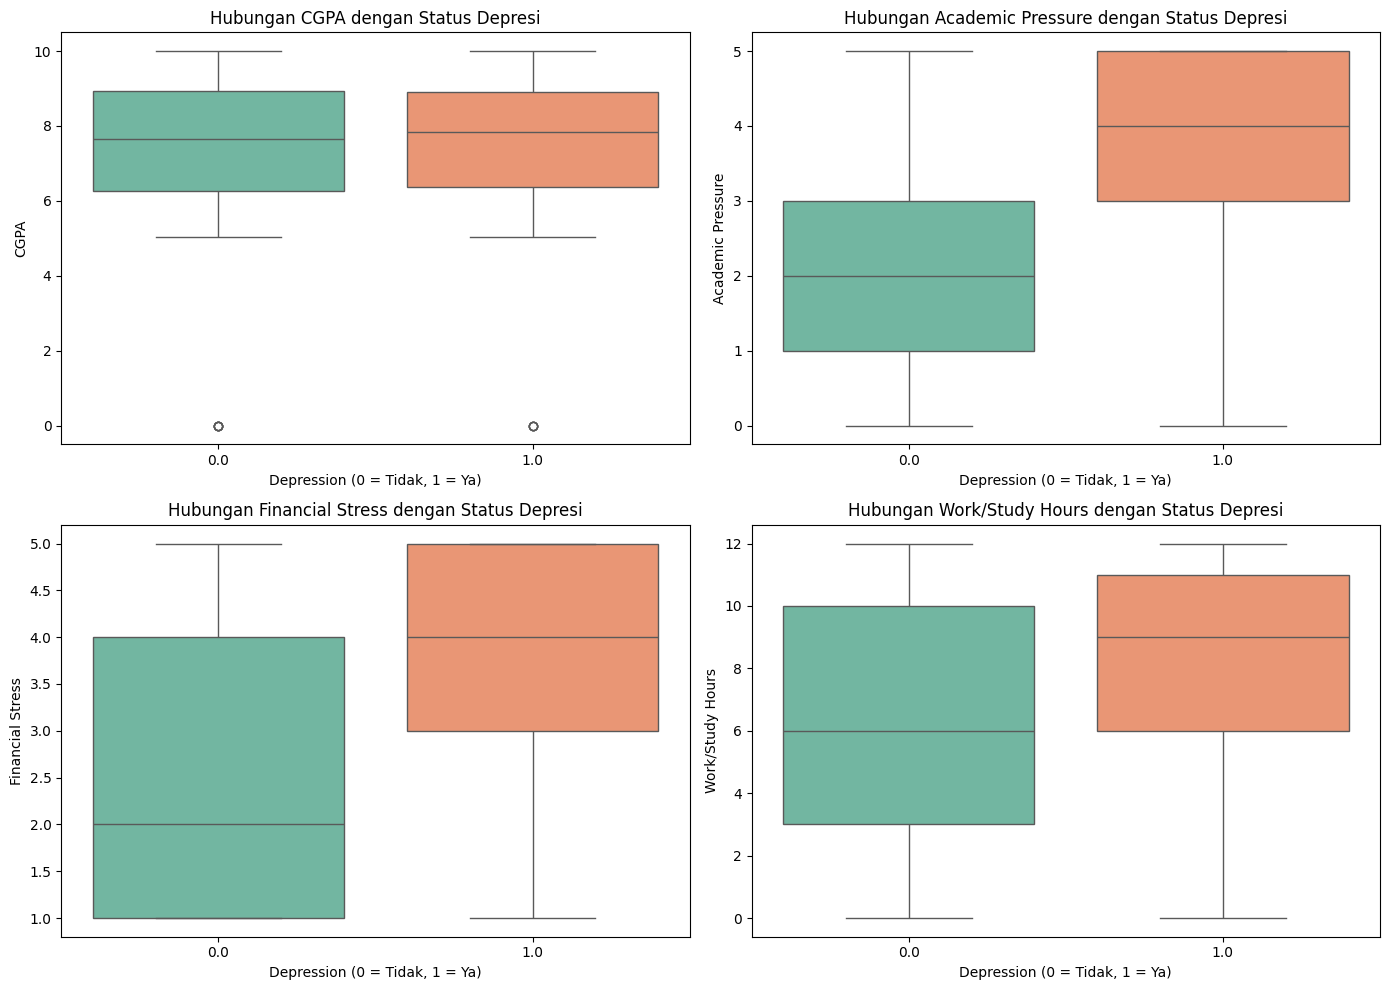

In [6]:
# Daftar fitur numerik yang akan dianalisis
numeric_features = ['CGPA', 'Academic Pressure', 'Financial Stress', 'Work/Study Hours']

# Membuat kanvas (figure) untuk menampung beberapa grafik sekaligus
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# Looping untuk membuat Boxplot pada setiap fitur numerik
for i, feature in enumerate(numeric_features):
    sns.boxplot(
        x='Depression',
        y=feature,
        data=df,
        ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(f'Hubungan {feature} dengan Status Depresi', fontsize=12)
    axes[i].set_xlabel('Depression (0 = Tidak, 1 = Ya)')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

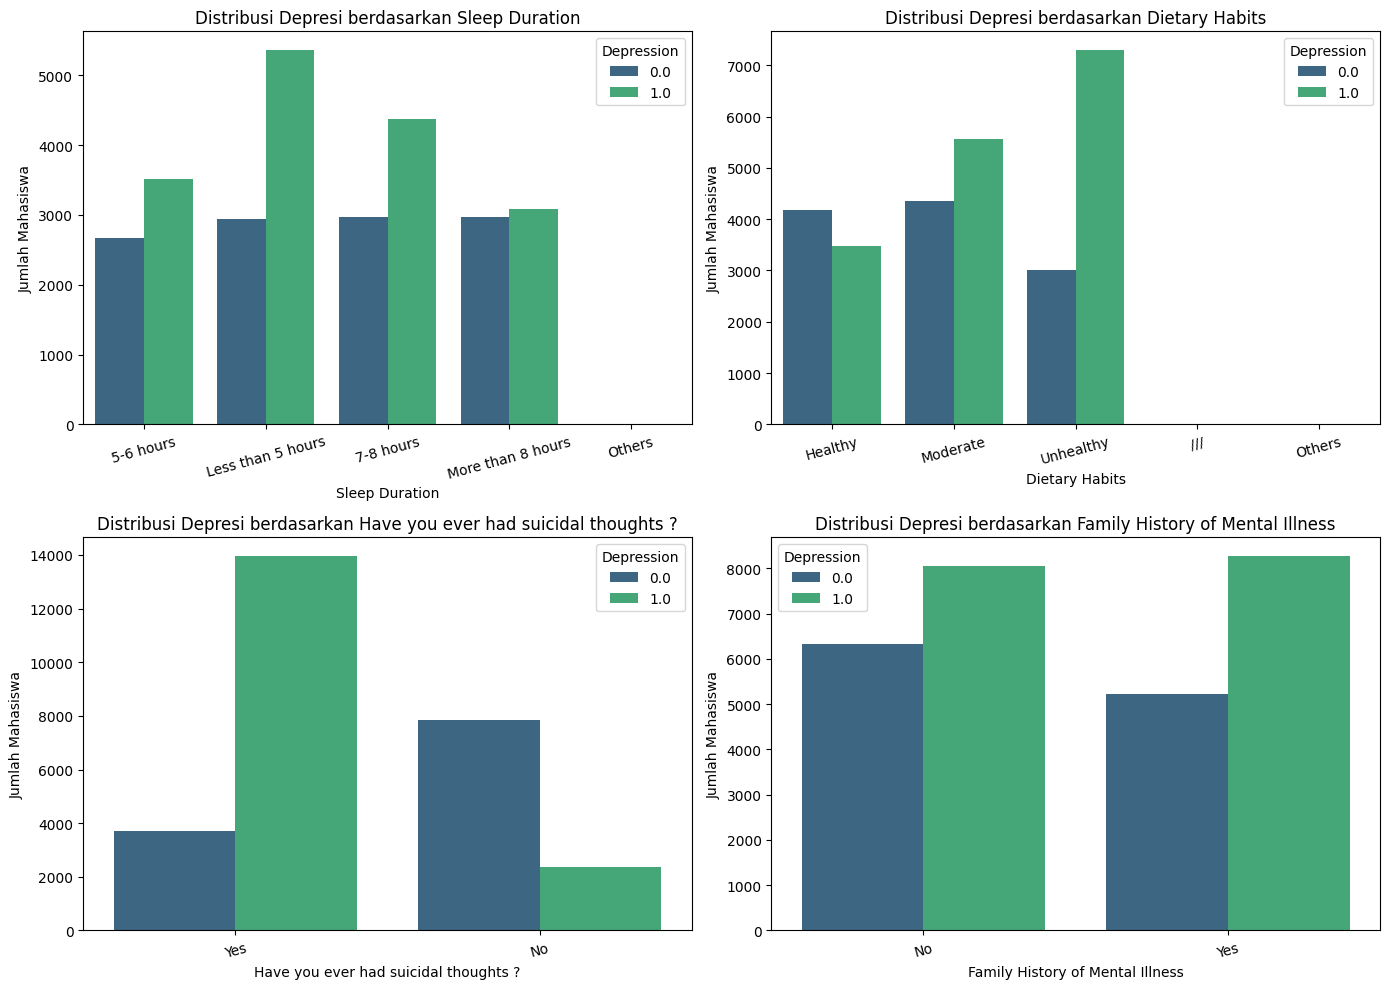

In [7]:
# Daftar fitur kategorik yang akan dianalisis
categorical_features = [
    'Sleep Duration',
    'Dietary Habits',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

# Membuat kanvas (figure)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# Looping untuk membuat Countplot (Grouped Bar Chart)
for i, feature in enumerate(categorical_features):
    sns.countplot(
        x=feature,
        hue='Depression',
        data=df,
        ax=axes[i],
        palette='viridis'
    )
    axes[i].set_title(f'Distribusi Depresi berdasarkan {feature}', fontsize=12)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Jumlah Mahasiswa')
    # Memutar label sumbu X jika teksnya terlalu panjang
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Analisis Multivariat dan correlation

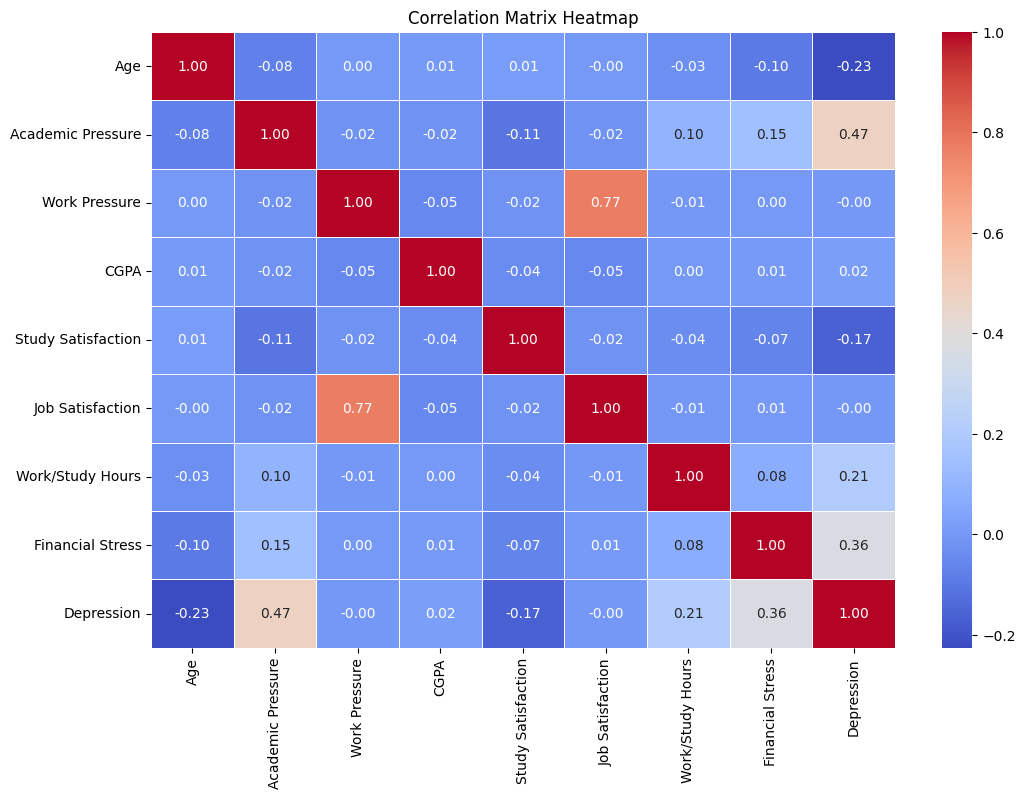

In [8]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

## Insight

Berdasarkan serangkaian eksplorasi data (Univariat, Bivariat, dan Multivariat) yang telah dilakukan terhadap dataset `Bengkod-Depresi.csv`, berikut adalah insight utama dan keputusan preprocessing yang akan diambil:

### 1. Ketimpangan Kelas pada Variabel Target (Imbalanced Data)
* **Insight:** Dari distribusi pie chart, terlihat ketimpangan yang sangat signifikan pada variabel target `Depression`. Sebanyak 81,3% mahasiswa masuk dalam kategori tidak depresi, sedangkan hanya 18,7% yang terdiagnosis depresi.
* **Keputusan Preprocessing:** Model Machine Learning akan cenderung bias menebak kelas mayoritas jika data ini dibiarkan. Oleh karena itu, pada tahap pemodelan nanti, **wajib diterapkan teknik over sampling** pada data latih (train set) untuk menyeimbangkan jumlah kelas.

### 2. Pengaruh Signifikan Stres Finansial & Kondisi Klinis
* **Insight:** Melalui analisis bivariat (Boxplot) dan heatmap korelasi, fitur `Financial Stress` dan `Academic Pressure` menunjukkan korelasi positif yang paling menonjol terhadap depresi. Selain itu, mahasiswa yang memiliki riwayat keluarga penyakit mental atau pikiran bunuh diri (`Suicidal thoughts`) memiliki rasio depresi yang jauh lebih dominan.
* **Keputusan Preprocessing:** Fitur-fitur ini sangat penting dan akan dipertahankan dalam **Feature Selection**. Untuk data biner (Yes/No), akan dilakukan **Binary Encoding (0 dan 1)**. Sedangkan semua fitur numerik (seperti skor stres, CGPA, dan umur) akan diskalakan menggunakan **StandardScaler** agar model dapat memproses perbedaan rentang angka secara adil.

### 3. Hierarki pada Pola Gaya Hidup
* **Insight:** Pola hidup memiliki dampak nyata. Kelompok mahasiswa dengan durasi tidur kurang dari 5 jam dan pola makan tidak sehat (*Unhealthy*) menyumbang proporsi depresi yang sangat tinggi dibandingkan mahasiswa dengan gaya hidup sehat.
* **Keputusan Preprocessing:** Karena fitur `Sleep Duration` dan `Dietary Habits` memiliki tingkatan (dari buruk ke baik), fitur tersebut tidak bisa diubah dengan One-Hot Encoding biasa. Fitur ini akan diproses menggunakan **Ordinal Encoding** agar algoritma model (seperti Decision Tree) dapat mengenali urutan hierarki keparahannya secara logis.

### Kesimpulan Feature Selection
Dari hasil *Correlation Heatmap*, tidak ditemukan korelasi antar fitur prediktor yang terlalu tinggi (multikolinearitas ekstrim). Selain itu, fitur dengan nilai seragam seperti `Profession` ("Student") dan berdimensi tinggi seperti `City` akan di drop karena berisiko menyebabkan *overfitting*. Sisa fitur yang ada saat ini sudah sangat ideal untuk dimasukkan ke dalam tahap pemodelan (*Modeling*).

# Direct Modelling


In [9]:
df_direct = df.copy()
df_direct.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1.0
1,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0.0
2,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0.0
3,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1.0
4,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0.0


In [10]:
le = LabelEncoder()
cat_cols = df_direct.select_dtypes(exclude=['number']).columns
for col in cat_cols:
    df_direct[col] = le.fit_transform(df_direct[col].astype(str))
df_direct.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33,51,11,5,0,8.97,2,0,0,1,3,1,3,1.0,0,1.0
1,0,24,3,11,2,0,5.90,5,0,0,2,10,0,3,2.0,1,0.0
2,1,31,44,11,3,0,7.03,5,0,2,1,5,0,9,1.0,1,0.0
3,0,28,49,11,3,0,5.59,2,0,1,2,7,1,4,5.0,1,1.0
4,0,25,16,11,4,0,8.13,3,0,0,2,17,1,1,1.0,0,0.0


In [11]:
X = df_direct.drop(columns=['Depression'])
y = df_direct['Depression']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')

Training set size: 22318 samples
Testing set size: 5580 samples


In [13]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.84      0.78      0.81      2348
         1.0       0.85      0.89      0.87      3232

    accuracy                           0.84      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.84      0.84      5580



Logistic Regression
Dipilih sebagai baseline model (model dasar). Algoritma ini sangat efisien, sederhana, dan paling transparan untuk melihat apakah terdapat hubungan linear yang kuat antara prediktor (seperti tingginya stres atau rendahnya jam tidur) terhadap probabilitas terjadinya depresi.

In [14]:
dt_classifier = DecisionTreeClassifier(random_state=42)

dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)

print("Classification Report for Decision Tree Classifier:")
print(classification_report(y_test, y_pred_dt))

Classification Report for Decision Tree Classifier:
              precision    recall  f1-score   support

         0.0       0.73      0.71      0.72      2348
         1.0       0.79      0.81      0.80      3232

    accuracy                           0.77      5580
   macro avg       0.76      0.76      0.76      5580
weighted avg       0.77      0.77      0.77      5580



Decision Tree Classifier
Dipilih karena kemampuannya menangkap interaksi logis antar variabel (misalnya: efek gabungan dari beban kerja tinggi DAN durasi tidur rendah). Model ini memiliki alur logika pengambilan keputusan yang sangat mudah dijelaskan dan diinterpretasikan saat presentasi.

In [15]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)

print("Classification Report for Random Forest Classifier:")
print(classification_report(y_test, y_pred_rf))

Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

         0.0       0.83      0.78      0.80      2348
         1.0       0.85      0.88      0.86      3232

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.83      5580
weighted avg       0.84      0.84      0.84      5580



Random Forest Classifier (Ensemble)
Sebagai model ansambel berbasis bagging, model ini dipilih untuk menutupi kelemahan Decision Tree tunggal yang rentan menghafal data (overfitting). Random Forest sangat tangguh (robust) dalam memproses dataset tabular yang memiliki campuran tipe data numerik dan kategorikal seperti milik Anda.

In [16]:
xgb_classifier = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='logloss')

xgb_classifier.fit(X_train, y_train)
y_pred_xgb = xgb_classifier.predict(X_test)

print("Classification Report for XGBoost Classifier:")
print(classification_report(y_test, y_pred_xgb))

Classification Report for XGBoost Classifier:
              precision    recall  f1-score   support

         0.0       0.84      0.78      0.81      2348
         1.0       0.85      0.89      0.87      3232

    accuracy                           0.84      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.84      0.84      5580



XGBoost Classifier (Ensemble)
Ini adalah algoritma State-of-the-Art (mutakhir) untuk data tabular. Dipilih karena mekanisme boosting-nya mampu secara aktif belajar dari kesalahan prediksi sebelumnya. Algoritma ini menjadi tumpuan utama untuk mendapatkan metrik performa (Akurasi dan F1-Score) yang paling maksimal.

In [17]:
svc_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, random_state=42))

svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)

print("Classification Report for Support Vector Classifier (SVC):")
print(classification_report(y_test, y_pred_svc))

Classification Report for Support Vector Classifier (SVC):
              precision    recall  f1-score   support

         0.0       0.84      0.77      0.80      2348
         1.0       0.84      0.90      0.87      3232

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.84      5580
weighted avg       0.84      0.84      0.84      5580



Support Vector Classifier (SVC)
Dipilih karena kemampuannya yang sangat presisi dalam mencari garis batas pemisah (hyperplane) paling optimal antara kelas mahasiswa yang depresi dan tidak depresi. Model ini juga sangat andal menangani dataset yang jumlah dimensinya/kolomnya membengkak setelah dilakukan tahapan encoding.

# Pre Processing

## Data Clean

In [18]:
df.drop(columns=['City',	'Profession' ], inplace=True)


drop Kolom (City & Profession)

**Alasan:**
*   **Profession:** Memiliki nilai yang seragam untuk semua baris ("Student"), sehingga tidak memberikan pola baru bagi model (zero variance).
*   **City:** Memiliki nilai unik yang terlalu banyak (high cardinality) yang berisiko membuat model menjadi overfitting.

## Encoding

### Ordinal Encoding

In [19]:
# Fix: Re-applying dropna after mapping and ensuring we handle potential NaNs from mapping mismatches
sleep_mapping = {'Less than 5 hours': 1, '5-6 hours': 2, '7-8 hours': 3, 'More than 8 hours': 4}
dietary_mapping = {'Unhealthy': 1, 'Moderate': 2, 'Healthy': 3}

# Only map if they are still strings, otherwise skip to avoid creating NaNs
if df['Sleep Duration'].dtype == 'object':
    df['Sleep Duration'] = df['Sleep Duration'].map(sleep_mapping)
if df['Dietary Habits'].dtype == 'object':
    df['Dietary Habits'] = df['Dietary Habits'].map(dietary_mapping)

# Final cleaning to remove any NaNs introduced during engineering
df.dropna(inplace=True)
print("Null values after fix:")
print(df.isnull().sum().sum())
display(df[['Sleep Duration', 'Dietary Habits']].head())

Null values after fix:
0


,Sleep Duration,Dietary Habits
0,2.0,3.0
1,2.0,2.0
2,1.0,3.0
3,3.0,2.0
4,2.0,2.0


Ordinal Encoding (Untuk Data Kategorik Bertingkat) pada `Sleep Duration` dan `Dietary Habits`.

**Alasan:** Fitur ini memiliki hierarki atau tingkatan kualitas yang memengaruhi kesehatan. Ordinal encoding memastikan algoritma (terutama algoritma berbasis pohon seperti Decision Tree dan XGBoost) memahami gradasi keparahan dari gaya hidup mahasiswa tersebut.

### Label Encode

In [20]:
binary_mapping = {
    'Gender': {'Male': 1, 'Female': 0},
    'Have you ever had suicidal thoughts ?': {'Yes': 1, 'No': 0},
    'Family History of Mental Illness': {'Yes': 1, 'No': 0}
}

for col, mapping in binary_mapping.items():
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].map(mapping)

df.head()

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33,5,0,8.97,2,0,2.0,3.0,B.Pharm,1,3,1.0,0,1.0
1,0,24,2,0,5.90,5,0,2.0,2.0,BSc,0,3,2.0,1,0.0
2,1,31,3,0,7.03,5,0,1.0,3.0,BA,0,9,1.0,1,0.0
3,0,28,3,0,5.59,2,0,3.0,2.0,BCA,1,4,5.0,1,1.0
4,0,25,4,0,8.13,3,0,2.0,2.0,M.Tech,1,1,1.0,0,0.0


### One Hot Encoding

In [21]:
if 'Degree' in df.columns and df['Degree'].dtype == 'object':
    df = pd.get_dummies(df, columns=['Degree'], drop_first=True)
else:
    print("Column 'Degree' already encoded or missing. Skipping One-Hot Encoding.")

df = df.replace({True: 1, False: 0})

df.head()

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,...,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD
0,1,33,5,0,8.97,2,0,2.0,3.0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,24,2,0,5.90,5,0,2.0,2.0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,31,3,0,7.03,5,0,1.0,3.0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,28,3,0,5.59,2,0,3.0,2.0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,25,4,0,8.13,3,0,2.0,2.0,1,...,0,0,0,0,0,0,0,0,0,0


### split 80:20

In [22]:
X_clean = df.drop(columns=['Depression'])
y_clean = df['Depression']

In [23]:
# Splitting the resampled data into training and testing sets
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

print(f'Final Training set size: {X_train_clean.shape[0]} samples')
print(f'Final Testing set size: {X_test_clean.shape[0]} samples')

Final Training set size: 22293 samples
Final Testing set size: 5574 samples


### Scaler

In [24]:
scaler = StandardScaler()
num_cols = [
    'Age', 'CGPA', 'Work/Study Hours',
    'Academic Pressure', 'Work Pressure',
    'Study Satisfaction', 'Job Satisfaction', 'Financial Stress'
]

# Ensure we use the variables from the train_test_split cell
existing_num_cols = [col for col in num_cols if col in X_train_clean.columns]

# Fit only on training set to prevent data leakage
X_train_clean[existing_num_cols] = scaler.fit_transform(X_train_clean[existing_num_cols])
X_test_clean[existing_num_cols] = scaler.transform(X_test_clean[existing_num_cols])

print("Scaling complete. Summary of scaled training features:")
display(X_train_clean[existing_num_cols].head())

Scaling complete. Summary of scaled training features:


,Age,CGPA,Work/Study Hours,Academic Pressure,Work Pressure,Study Satisfaction,Job Satisfaction,Financial Stress
5025,1.463539,0.289669,1.307989,-1.549486,-0.009472,0.037170,-0.016408,0.604487
12423,1.055292,-1.138419,0.229484,0.620327,-0.009472,0.037170,-0.016408,1.300085
14682,-1.190065,0.255504,0.768737,1.343598,-0.009472,0.771124,-0.016408,-0.786710
13078,1.055292,-1.650890,-1.927526,-0.102944,-0.009472,0.037170,-0.016408,1.300085
18235,0.034675,-0.516620,1.038363,-1.549486,-0.009472,0.037170,-0.016408,1.300085


### Feature Selection

In [25]:
from sklearn.feature_selection import f_classif, SelectKBest
import pandas as pd

# Perform Univariate Feature Selection (ANOVA F-test)
# This calculates the F-score and p-value for each feature
f_scores, p_values = f_classif(X_train_clean, y_train_clean)

# Create a DataFrame to display results
univariate_results = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'F-Score': f_scores,
    'p-value': p_values
})

# Sort by p-value (lowest p-value means highest significance)
univariate_results = univariate_results.sort_values(by='p-value', ascending=True)

print("Univariate Analysis Results (sorted by p-value):")
display(univariate_results.head(20))

# Select top k features based on the analysis
k = 15
selected_features = univariate_results['Feature'].iloc[:k].tolist()

print(f"\nSelected top {k} features based on lowest p-values:")
print(selected_features)

# Prepare final training and testing sets
X_train_final = X_train_clean[selected_features]
X_test_final = X_test_clean[selected_features]

Univariate Analysis Results (sorted by p-value):


,Feature,F-Score,p-value
2,Academic Pressure,6393.980311,0.000000e+00
9,Have you ever had suicidal thoughts ?,9612.465546,0.000000e+00
11,Financial Stress,3394.550053,0.000000e+00
1,Age,1238.258874,4.842968e-264
10,Work/Study Hours,987.861514,3.307110e-212
8,Dietary Habits,983.009646,3.384044e-211
5,Study Satisfaction,678.404565,2.374587e-147
23,Degree_Class 12,405.450521,2.236024e-89
7,Sleep Duration,180.399162,5.723686e-41
12,Family History of Mental Illness,72.051824,2.225151e-17



Selected top 15 features based on lowest p-values:
['Academic Pressure', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Age', 'Work/Study Hours', 'Dietary Habits', 'Study Satisfaction', 'Degree_Class 12', 'Sleep Duration', 'Family History of Mental Illness', 'Degree_M.Ed', 'Degree_M.Tech', 'Degree_MCA', 'Degree_B.Ed', 'Degree_MD']


### Over-Sampling

In [26]:
# Initialize SMOTETomek
smt = SMOTETomek(random_state=42)

# Apply to the final training data (after feature selection)
X_train_resampled, y_train_resampled = smt.fit_resample(X_train_final, y_train_clean)

print(f'Original training set shape: {X_train_final.shape}')
print(f'Resampled training set shape: {X_train_resampled.shape}')

Original training set shape: (22293, 15)
Resampled training set shape: (24488, 15)


### Modelling

In [27]:
# Logistic Regression
log_reg_final = LogisticRegression(max_iter=1000)
log_reg_final.fit(X_train_resampled, y_train_resampled)
y_pred_log_final = log_reg_final.predict(X_test_final)

print("--- Logistic Regression ---")
print(classification_report(y_test_clean, y_pred_log_final))

--- Logistic Regression ---
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81      2255
         1.0       0.88      0.85      0.86      3319

    accuracy                           0.84      5574
   macro avg       0.83      0.84      0.84      5574
weighted avg       0.84      0.84      0.84      5574



In [28]:
# Hyperparameter Tuning for Logistic Regression
param_grid_log = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}
grid_log = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_log, cv=5, scoring='accuracy')
grid_log.fit(X_train_resampled, y_train_resampled)

print(f"Best Parameters (Logistic Regression): {grid_log.best_params_}")
y_pred_log_tuned = grid_log.predict(X_test_final)
print(classification_report(y_test_clean, y_pred_log_tuned))

Best Parameters (Logistic Regression): {'C': 0.1, 'solver': 'liblinear'}
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81      2255
         1.0       0.88      0.85      0.86      3319

    accuracy                           0.84      5574
   macro avg       0.83      0.84      0.84      5574
weighted avg       0.84      0.84      0.84      5574



In [29]:
# Decision Tree
dt_final = DecisionTreeClassifier(random_state=42)
dt_final.fit(X_train_resampled, y_train_resampled)
y_pred_dt_final = dt_final.predict(X_test_final)

print("--- Decision Tree ---")
print(classification_report(y_test_clean, y_pred_dt_final))

--- Decision Tree ---
              precision    recall  f1-score   support

         0.0       0.71      0.73      0.72      2255
         1.0       0.81      0.80      0.81      3319

    accuracy                           0.77      5574
   macro avg       0.76      0.77      0.76      5574
weighted avg       0.77      0.77      0.77      5574



In [30]:
# Hyperparameter Tuning for Decision Tree
param_grid_dt = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train_resampled, y_train_resampled)

print(f"Best Parameters (Decision Tree): {grid_dt.best_params_}")
y_pred_dt_tuned = grid_dt.predict(X_test_final)
print(classification_report(y_test_clean, y_pred_dt_tuned))

Best Parameters (Decision Tree): {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}
              precision    recall  f1-score   support

         0.0       0.78      0.79      0.78      2255
         1.0       0.85      0.85      0.85      3319

    accuracy                           0.82      5574
   macro avg       0.82      0.82      0.82      5574
weighted avg       0.82      0.82      0.82      5574



In [31]:
# Random Forest
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train_resampled, y_train_resampled)
y_pred_rf_final = rf_final.predict(X_test_final)

print("--- Random Forest ---")
print(classification_report(y_test_clean, y_pred_rf_final))

--- Random Forest ---
              precision    recall  f1-score   support

         0.0       0.80      0.80      0.80      2255
         1.0       0.86      0.86      0.86      3319

    accuracy                           0.84      5574
   macro avg       0.83      0.83      0.83      5574
weighted avg       0.84      0.84      0.84      5574



In [32]:
# Hyperparameter Tuning for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='accuracy')
grid_rf.fit(X_train_resampled, y_train_resampled)

print(f"Best Parameters (Random Forest): {grid_rf.best_params_}")
y_pred_rf_tuned = grid_rf.predict(X_test_final)
print(classification_report(y_test_clean, y_pred_rf_tuned))

Best Parameters (Random Forest): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

         0.0       0.80      0.80      0.80      2255
         1.0       0.86      0.86      0.86      3319

    accuracy                           0.84      5574
   macro avg       0.83      0.83      0.83      5574
weighted avg       0.84      0.84      0.84      5574



In [33]:
# XGBoost
xgb_final = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, eval_metric='logloss')
xgb_final.fit(X_train_resampled, y_train_resampled)
y_pred_xgb_final = xgb_final.predict(X_test_final)

print("--- XGBoost ---")
print(classification_report(y_test_clean, y_pred_xgb_final))

--- XGBoost ---
              precision    recall  f1-score   support

         0.0       0.81      0.81      0.81      2255
         1.0       0.87      0.87      0.87      3319

    accuracy                           0.84      5574
   macro avg       0.84      0.84      0.84      5574
weighted avg       0.84      0.84      0.84      5574



In [34]:
# Hyperparameter Tuning for XGBoost
param_grid_xgb = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6],
    'n_estimators': [50, 100]
}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), param_grid_xgb, cv=3, scoring='accuracy')
grid_xgb.fit(X_train_resampled, y_train_resampled)

print(f"Best Parameters (XGBoost): {grid_xgb.best_params_}")
y_pred_xgb_tuned = grid_xgb.predict(X_test_final)
print(classification_report(y_test_clean, y_pred_xgb_tuned))

Best Parameters (XGBoost): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
              precision    recall  f1-score   support

         0.0       0.80      0.81      0.80      2255
         1.0       0.87      0.86      0.86      3319

    accuracy                           0.84      5574
   macro avg       0.83      0.84      0.83      5574
weighted avg       0.84      0.84      0.84      5574



In [35]:
# Support Vector Classifier (SVC)
svc_final = SVC(kernel='rbf', C=1.0, random_state=42)
svc_final.fit(X_train_resampled, y_train_resampled)
y_pred_svc_final = svc_final.predict(X_test_final)

print("--- Support Vector Classifier (SVC) ---")
print(classification_report(y_test_clean, y_pred_svc_final))

--- Support Vector Classifier (SVC) ---
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81      2255
         1.0       0.88      0.85      0.87      3319

    accuracy                           0.84      5574
   macro avg       0.84      0.84      0.84      5574
weighted avg       0.84      0.84      0.84      5574



In [36]:
# Hyperparameter Tuning for Support Vector Classifier (SVC)
# Note: Reduced grid size due to SVC complexity
param_grid_svc = {
    'C': [0.1, 1],
    'kernel': ['rbf']
}
grid_svc = GridSearchCV(SVC(random_state=42), param_grid_svc, cv=3, scoring='accuracy')
grid_svc.fit(X_train_resampled, y_train_resampled)

print(f"Best Parameters (SVC): {grid_svc.best_params_}")
y_pred_svc_tuned = grid_svc.predict(X_test_final)
print(classification_report(y_test_clean, y_pred_svc_tuned))

Best Parameters (SVC): {'C': 0.1, 'kernel': 'rbf'}
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81      2255
         1.0       0.88      0.85      0.86      3319

    accuracy                           0.84      5574
   macro avg       0.83      0.84      0.84      5574
weighted avg       0.84      0.84      0.84      5574



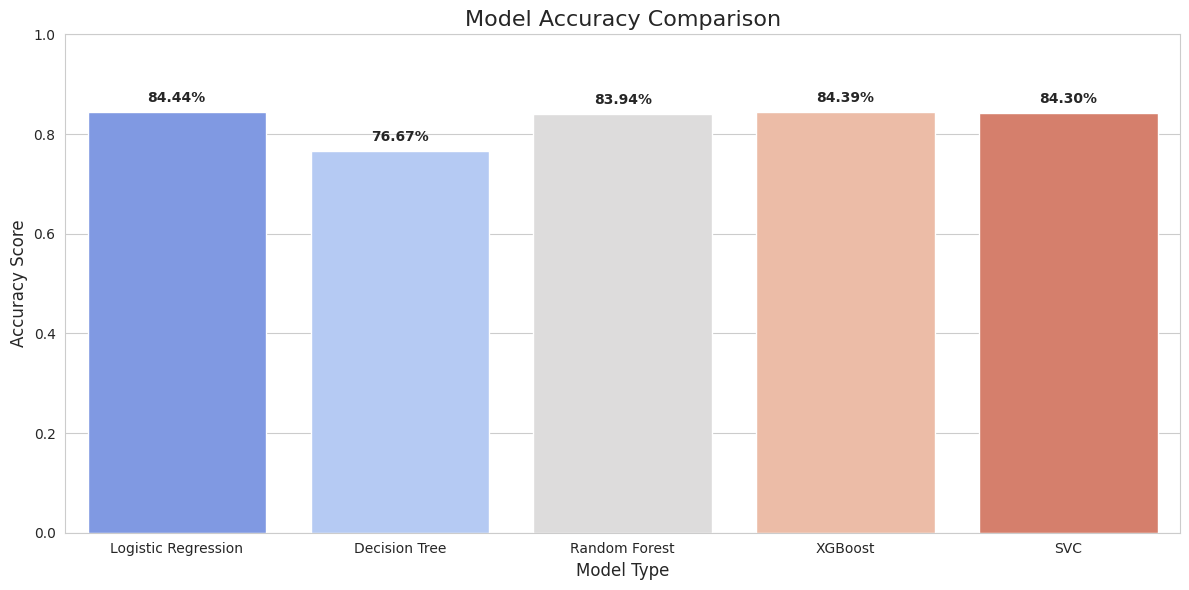

In [37]:

initial_models = {
  'Logistic Regression': accuracy_score(y_test, y_pred),
  'Decision Tree': accuracy_score(y_test, y_pred_dt),
  'Random Forest': accuracy_score(y_test, y_pred_rf),
  'XGBoost': accuracy_score(y_test, y_pred_xgb),
  'SVC': accuracy_score(y_test, y_pred_svc)
}

model_names = list(initial_models.keys())
accuracy_values = list(initial_models.values())

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=model_names, y=accuracy_values, palette='coolwarm')

plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model Type', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.0)

for i, val in enumerate(accuracy_values):
  ax.text(i, val + 0.02, f'{val:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


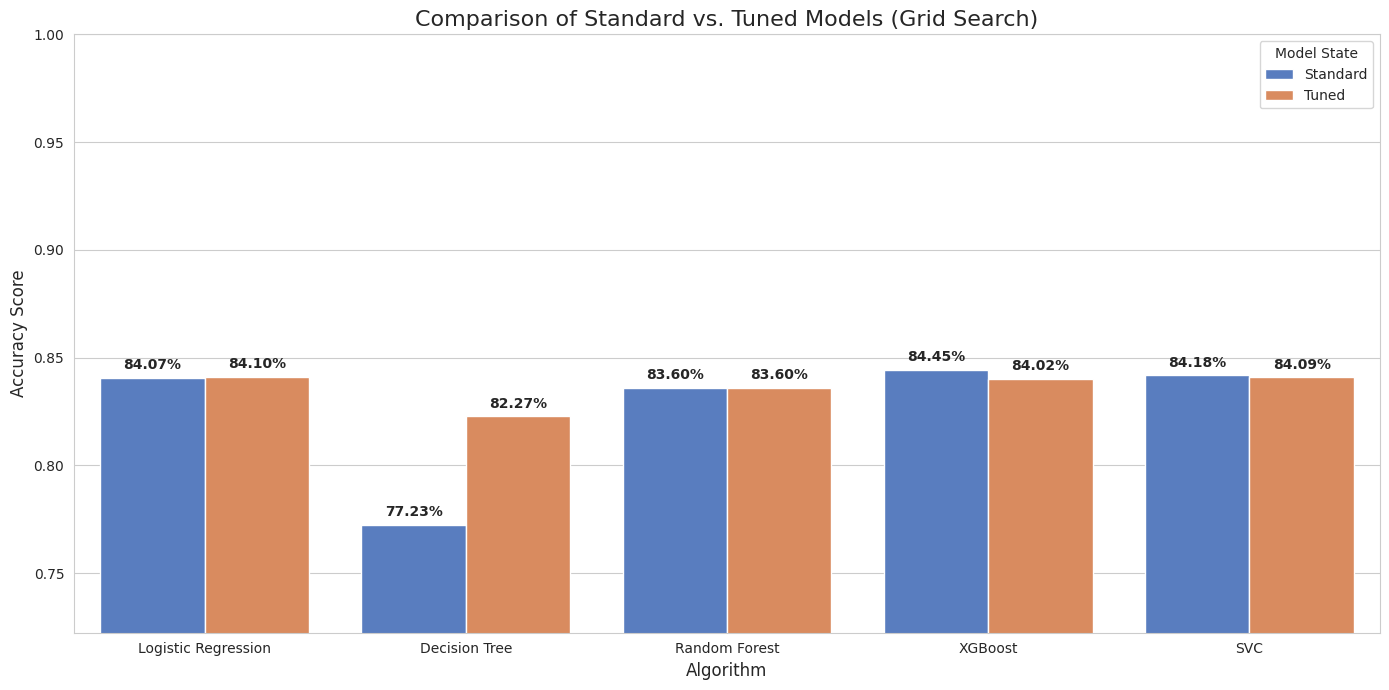

In [38]:
comparison_data = {
    'Model': ['Logistic Regression', 'Logistic Regression', 'Decision Tree', 'Decision Tree',
              'Random Forest', 'Random Forest', 'XGBoost', 'XGBoost', 'SVC', 'SVC'],
    'Type': ['Standard', 'Tuned', 'Standard', 'Tuned', 'Standard', 'Tuned', 'Standard', 'Tuned', 'Standard', 'Tuned'],
    'Accuracy': [
        accuracy_score(y_test_clean, y_pred_log_final),
        accuracy_score(y_test_clean, y_pred_log_tuned),
        accuracy_score(y_test_clean, y_pred_dt_final),
        accuracy_score(y_test_clean, y_pred_dt_tuned),
        accuracy_score(y_test_clean, y_pred_rf_final),
        accuracy_score(y_test_clean, y_pred_rf_tuned),
        accuracy_score(y_test_clean, y_pred_xgb_final),
        accuracy_score(y_test_clean, y_pred_xgb_tuned),
        accuracy_score(y_test_clean, y_pred_svc_final),
        accuracy_score(y_test_clean, y_pred_svc_tuned)
    ]
}

df_compare = pd.DataFrame(comparison_data)

# Visualization
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_compare, x='Model', y='Accuracy', hue='Type', palette='muted')

plt.title('Comparison of Standard vs. Tuned Models (Grid Search)', fontsize=16)
plt.xlabel('Algorithm', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(min(df_compare['Accuracy']) - 0.05, 1.0)
plt.legend(title='Model State', loc='upper right')

# Adding values on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2%}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [41]:
# Memilih model terbaik hasil tuning (misalnya SVC atau XGBoost)
best_model = grid_xgb.best_estimator_

# Menyimpan model ke format .pkl
model_filename = 'model.pkl'
joblib.dump(best_model, model_filename)

print(f'Model berhasil diekspor sebagai: {model_filename}')

Model berhasil diekspor sebagai: model.pkl
